In [ ]:
#Instalación de librerías
%pip install alpaca-py scikit-learn pandas numpy matplotlib seaborn joblib pytz python-dotenv 

In [1]:
# Imports generales
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Fechas
from datetime import datetime

# Alpaca — obtención de datos
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

# Scikit-learn — preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Scikit-learn — modelos
from sklearn.linear_model import LinearRegression, Ridge, BayesianRidge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# Scikit-learn — métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Guardar modelos
import joblib

# Configuración visual
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("!!Librerías cargadas correctamente")

!!Librerías cargadas correctamente


In [2]:
# Credenciales de Alpaca (Paper Trading)

from dotenv import load_dotenv
import os

# Cargar variables del .env
load_dotenv()

API_KEY = os.getenv("API_KEY")
SECRET_TOKEN = os.getenv("SECRET_TOKEN")

# Validación 
if not API_KEY or not SECRET_TOKEN:
    raise ValueError("Faltan credenciales en el archivo .env")

client = StockHistoricalDataClient(API_KEY, SECRET_TOKEN)

print("Cliente de Alpaca conectado")

Cliente de Alpaca conectado


In [3]:
#  Descarga de datos históricos de INTC

request_params = StockBarsRequest(
    symbol_or_symbols="INTC",
    timeframe=TimeFrame.Day,          # Barras diarias
    start=datetime(2019, 1, 1),       # Desde enero 2019
    end=datetime(2024, 12, 31),       # Hasta diciembre 2024
    feed="iex"                        # Feed gratuito
)

# Solicitud a la API
bars = client.get_stock_bars(request_params)

# Convertir a DataFrame
df_raw = bars.df.reset_index()

# Vista previa
print(f"Datos descargados: {df_raw.shape[0]} registros, {df_raw.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{df_raw.columns.tolist()}")
print(f"\nPrimeras filas:")
df_raw.head()

Datos descargados: 1115 registros, 9 columnas

Columnas disponibles:
['symbol', 'timestamp', 'open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap']

Primeras filas:


,symbol,timestamp,open,high,low,close,volume,trade_count,vwap
0,INTC,2020-07-27 04:00:00+00:00,51.03,51.135,49.51,49.545,2381133.0,13266.0,50.125079
1,INTC,2020-07-28 04:00:00+00:00,49.51,50.190,49.14,49.240,1072342.0,6455.0,49.622185
2,INTC,2020-07-29 04:00:00+00:00,49.43,49.470,47.90,48.085,1115663.0,7770.0,48.271563
3,INTC,2020-07-30 04:00:00+00:00,47.81,48.485,47.59,47.990,538909.0,4731.0,47.943802
4,INTC,2020-07-31 04:00:00+00:00,48.12,48.305,47.00,47.720,524091.0,4089.0,47.639135


In [4]:
# Limpieza inicial del DataFrame

# La columna 'symbol' no aporta información (siempre es "INTC")
df_raw = df_raw.drop(columns=["symbol"])

# Aseguramos que timestamp sea de tipo datetime y lo usamos como índice
df_raw["timestamp"] = pd.to_datetime(df_raw["timestamp"])
df_raw = df_raw.set_index("timestamp")

# Verificamos que no haya nulos
print(f"Valores nulos por columna:")
print(df_raw.isnull().sum())
print(f"\nShape del dataset: {df_raw.shape}")
df_raw.head()

Valores nulos por columna:
open           0
high           0
low            0
close          0
volume         0
trade_count    0
vwap           0
dtype: int64

Shape del dataset: (1115, 7)


,open,high,low,close,volume,trade_count,vwap
timestamp,,,,,,,
2020-07-27 04:00:00+00:00,51.03,51.135,49.51,49.545,2381133.0,13266.0,50.125079
2020-07-28 04:00:00+00:00,49.51,50.190,49.14,49.240,1072342.0,6455.0,49.622185
2020-07-29 04:00:00+00:00,49.43,49.470,47.90,48.085,1115663.0,7770.0,48.271563
2020-07-30 04:00:00+00:00,47.81,48.485,47.59,47.990,538909.0,4731.0,47.943802
2020-07-31 04:00:00+00:00,48.12,48.305,47.00,47.720,524091.0,4089.0,47.639135


In [5]:
# Ingeniería de características

df = df_raw.copy()

# 1 Retorno diario
# Variación porcentual del precio de cierre respecto al día anterior
df["daily_return"] = df["close"].pct_change()

# 2 Medias móviles 
# Promedio del precio de cierre en los últimos N días
df["ma_7"]  = df["close"].rolling(window=7).mean()
df["ma_21"] = df["close"].rolling(window=21).mean()

# 3 Volatilidad
# Qué tanto varía el precio en los últimos 7 días
df["volatility_7"] = df["daily_return"].rolling(window=7).std()

# 4 Rango diario
# Diferencia entre el precio más alto y más bajo del día
df["daily_range"] = df["high"] - df["low"]

# 5 Variable objetivo (target)
# El precio de cierre del día SIGUIENTE es lo que queremos predecir
df["target"] = df["close"].shift(-1)

# Eliminar filas con NaN 
df = df.dropna()

print(f"Características creadas correctamente")
print(f"Shape del dataset: {df.shape}")
print(f"\nColumnas del dataset:")
print(df.columns.tolist())
df.head()

Características creadas correctamente
Shape del dataset: (1094, 13)

Columnas del dataset:
['open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'daily_return', 'ma_7', 'ma_21', 'volatility_7', 'daily_range', 'target']


,open,high,low,close,volume,trade_count,vwap,daily_return,ma_7,ma_21,volatility_7,daily_range,target
timestamp,,,,,,,,,,,,,
2020-08-24 04:00:00+00:00,49.350,49.385,48.820,49.135,308299.0,3046.0,49.061107,-0.003044,48.912143,48.714048,0.007865,0.565,49.445
2020-08-25 04:00:00+00:00,49.305,49.860,49.220,49.445,459442.0,3638.0,49.439455,0.006309,48.989286,48.709286,0.007779,0.640,49.515
2020-08-26 04:00:00+00:00,49.355,49.665,49.240,49.515,237884.0,2183.0,49.484368,0.001416,49.075000,48.722381,0.007756,0.425,49.430
2020-08-27 04:00:00+00:00,49.780,49.920,49.195,49.430,281181.0,2319.0,49.583347,-0.001717,49.188571,48.786429,0.007242,0.725,50.405
2020-08-28 04:00:00+00:00,49.505,50.800,49.495,50.405,460013.0,3417.0,50.323914,0.019725,49.480000,48.901429,0.008787,1.305,51.035


In [6]:
# Normalización de los datos

# Separamos las características (X) del target (y)
# El target no se normaliza — queremos predicciones del precio real
X = df.drop(columns=["target"])
y = df["target"]

# Aplicamos StandardScaler a las características
# StandardScaler transforma cada columna para que tenga:
#   - Media = 0
#   - Desviación estándar = 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertimos de vuelta a DataFrame para mantener los nombres de columnas
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("Normalización completada")
print(f"\nEstadísticas post-normalización:")
print(X_scaled.describe().round(2))

Normalización completada

Estadísticas post-normalización:
          open     high      low    close   volume  trade_count     vwap  \
count  1094.00  1094.00  1094.00  1094.00  1094.00      1094.00  1094.00   
mean      0.00     0.00     0.00    -0.00     0.00        -0.00     0.00   
std       1.00     1.00     1.00     1.00     1.00         1.00     1.00   
min      -1.82    -1.84    -1.83    -1.83    -1.19        -1.89    -1.84   
25%      -0.86    -0.86    -0.85    -0.86    -0.64        -0.69    -0.86   
50%       0.01    -0.01    -0.02    -0.01    -0.25        -0.17    -0.01   
75%       0.83     0.82     0.83     0.83     0.28         0.44     0.83   
max       2.31     2.28     2.24     2.32     7.55         7.48     2.28   

       daily_return     ma_7    ma_21  volatility_7  daily_range  
count       1094.00  1094.00  1094.00       1094.00      1094.00  
mean          -0.00    -0.00     0.00         -0.00        -0.00  
std            1.00     1.00     1.00          1.00    

In [7]:
# Guardar datos procesados

# Guardamos el dataset procesado en CSV para que el equipo lo use
df.to_csv("../data/intc_processed.csv")
X_scaled.to_csv("../data/intc_X_scaled.csv")
y.to_csv("../data/intc_y.csv")

# Guardamos el scaler entrenado para usarlo en predicciones futuras
joblib.dump(scaler, "../models/scaler.pkl")

print("Dataset procesado guardado en /data/intc_processed.csv")
print("X escalado guardado en /data/intc_X_scaled.csv")
print("y guardado en /data/intc_y.csv")
print("Scaler guardado en /models/scaler.pkl")

Dataset procesado guardado en /data/intc_processed.csv
X escalado guardado en /data/intc_X_scaled.csv
y guardado en /data/intc_y.csv
Scaler guardado en /models/scaler.pkl


In [ ]:
#Aqui Empieza Oswaldo con el punto 2

In [8]:
# EDA | Gráficas analíticas del dataset
import matplotlib.dates as mdates

# Carpeta donde se van a guardar las graficas
os.makedirs("../plots", exist_ok=True)

# Verificamos que el df sigue disponible con todas sus columnas
print(f"Registros disponibles: {df.shape[0]}")
print(f"Columnas: {df.columns.tolist()}")
df.head()

Registros disponibles: 1094
Columnas: ['open', 'high', 'low', 'close', 'volume', 'trade_count', 'vwap', 'daily_return', 'ma_7', 'ma_21', 'volatility_7', 'daily_range', 'target']


,open,high,low,close,volume,trade_count,vwap,daily_return,ma_7,ma_21,volatility_7,daily_range,target
timestamp,,,,,,,,,,,,,
2020-08-24 04:00:00+00:00,49.350,49.385,48.820,49.135,308299.0,3046.0,49.061107,-0.003044,48.912143,48.714048,0.007865,0.565,49.445
2020-08-25 04:00:00+00:00,49.305,49.860,49.220,49.445,459442.0,3638.0,49.439455,0.006309,48.989286,48.709286,0.007779,0.640,49.515
2020-08-26 04:00:00+00:00,49.355,49.665,49.240,49.515,237884.0,2183.0,49.484368,0.001416,49.075000,48.722381,0.007756,0.425,49.430
2020-08-27 04:00:00+00:00,49.780,49.920,49.195,49.430,281181.0,2319.0,49.583347,-0.001717,49.188571,48.786429,0.007242,0.725,50.405
2020-08-28 04:00:00+00:00,49.505,50.800,49.495,50.405,460013.0,3417.0,50.323914,0.019725,49.480000,48.901429,0.008787,1.305,51.035


In [9]:
# Estadísticas descriptivas e interpretación
# Estadisticas generales del dataset de INTC
# Esto nos da una primera vision del comportamiento del activo

print(df.describe().round(4))

            open       high        low      close        volume  trade_count  \
count  1094.0000  1094.0000  1094.0000  1094.0000  1.094000e+03    1094.0000   
mean     40.6678    41.1955    40.1294    40.6595  1.074859e+06    8115.8867   
std      11.9056    11.9982    11.8110    11.9069  7.085632e+05    3601.7509   
min      18.9600    19.1000    18.5200    18.9000  2.313070e+05    1327.0000   
25%      30.3750    30.8412    30.0512    30.4275  6.240192e+05    5623.7500   
50%      40.7500    41.0875    39.9200    40.5850  8.946930e+05    7501.5000   
75%      50.5188    51.0238    49.9500    50.5287  1.273060e+06    9702.0000   
max      68.2000    68.4800    66.6300    68.2650  6.421167e+06   35051.0000   

            vwap  daily_return       ma_7      ma_21  volatility_7  \
count  1094.0000     1094.0000  1094.0000  1094.0000     1094.0000   
mean     40.6566       -0.0005    40.7384    40.9198        0.0221   
std      11.9069        0.0252    11.8185    11.6276        0.0118   

In [13]:
# Sacamos los valores mas importantes para interpretarlos

print(f"Precio promedio de cierre   : ${df['close'].mean():.2f} USD")
print(f"Precio minimo registrado    : ${df['close'].min():.2f} USD")
print(f"Precio maximo registrado    : ${df['close'].max():.2f} USD")
print(f"Retorno diario promedio     : {df['daily_return'].mean()*100:.4f}%")
print(f"Volatilidad promedio (7d)   : {df['volatility_7'].mean()*100:.4f}%")
print(f"Volumen promedio diario     : {df['volume'].mean():,.0f} acciones")
print(f"Rango diario promedio       : ${df['daily_range'].mean():.4f} USD")
print(f"Dias con retorno positivo   : {(df['daily_return'] > 0).mean()*100:.1f}%")
print(f"Dias con retorno negativo   : {(df['daily_return'] < 0).mean()*100:.1f}%")

Precio promedio de cierre   : $40.66 USD
Precio minimo registrado    : $18.90 USD
Precio maximo registrado    : $68.27 USD
Retorno diario promedio     : -0.0484%
Volatilidad promedio (7d)   : 2.2096%
Volumen promedio diario     : 1,074,859 acciones
Rango diario promedio       : $1.0661 USD
Dias con retorno positivo   : 49.5%
Dias con retorno negativo   : 49.7%


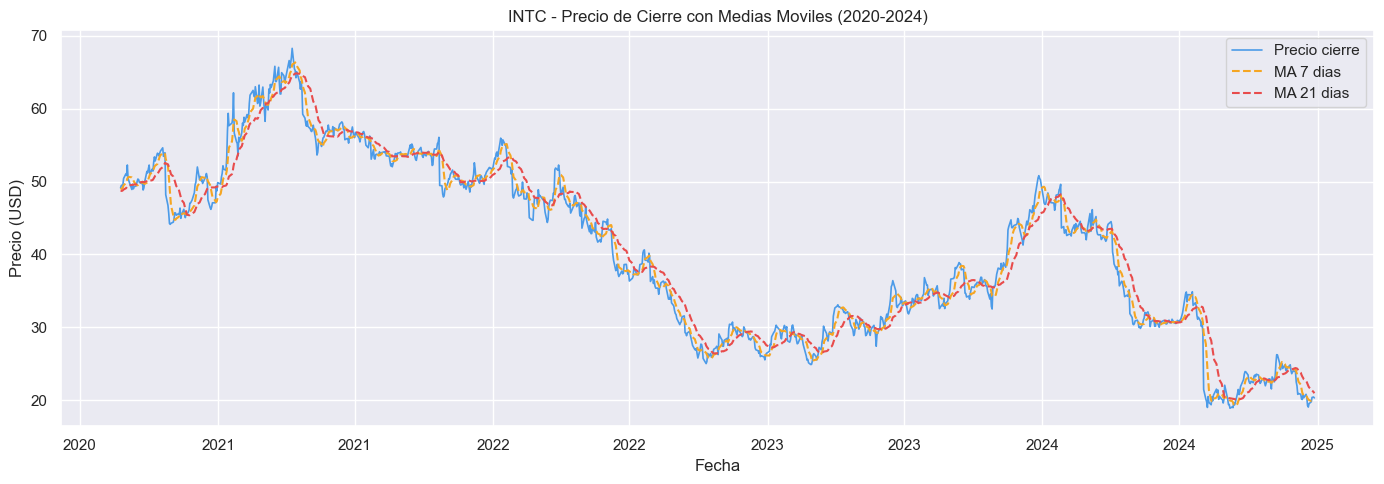

In [11]:
#Gráfica 1 — Precio de cierre con medias móviles
# Graficamos el precio historico de INTC junto a las medias moviles
# ma_7 y ma_21 fueron calculadas en el preprocesamiento por Jonathan
# Nos ayudan a ver la tendencia general del precio en el tiempo

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df["close"], color="#4C9BE8", linewidth=1.2, label="Precio cierre")
ax.plot(df.index, df["ma_7"],  color="#F5A623", linewidth=1.5,
        linestyle="--", label="MA 7 dias")
ax.plot(df.index, df["ma_21"], color="#E84C4C", linewidth=1.5,
        linestyle="--", label="MA 21 dias")

ax.set_title("INTC - Precio de Cierre con Medias Moviles (2020-2024)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (USD)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../plots/01_precio_ma.png", dpi=150)
plt.show()

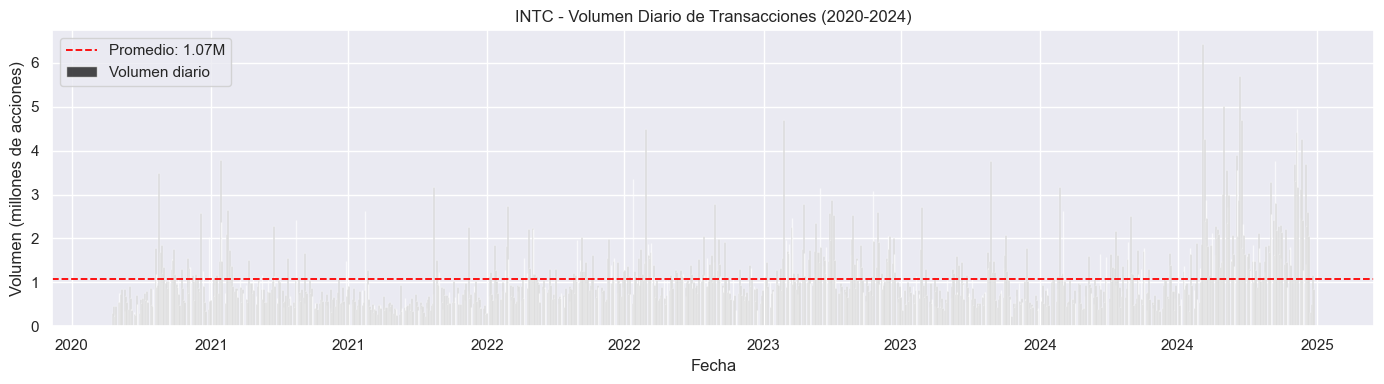

Volumen maximo en un dia : 6.42M acciones
Volumen minimo en un dia : 0.23M acciones


In [14]:
#Gráfica 2 — Volumen de transacciones
# Volumen diario de INTC
# Los picos de volumen suelen coincidir con noticias importantes
# o con los reportes de resultados trimestrales de Intel

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(df.index, df["volume"] / 1_000_000,
       color="#000000", alpha=0.7, width=1, label="Volumen diario")
ax.axhline(df["volume"].mean() / 1_000_000, color="red", linestyle="--",
           linewidth=1.3, label=f"Promedio: {df['volume'].mean()/1e6:.2f}M")

ax.set_title("INTC - Volumen Diario de Transacciones (2020-2024)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Volumen (millones de acciones)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../plots/02_volumen.png", dpi=150)
plt.show()

print(f"Volumen maximo en un dia : {df['volume'].max()/1e6:.2f}M acciones")
print(f"Volumen minimo en un dia : {df['volume'].min()/1e6:.2f}M acciones")

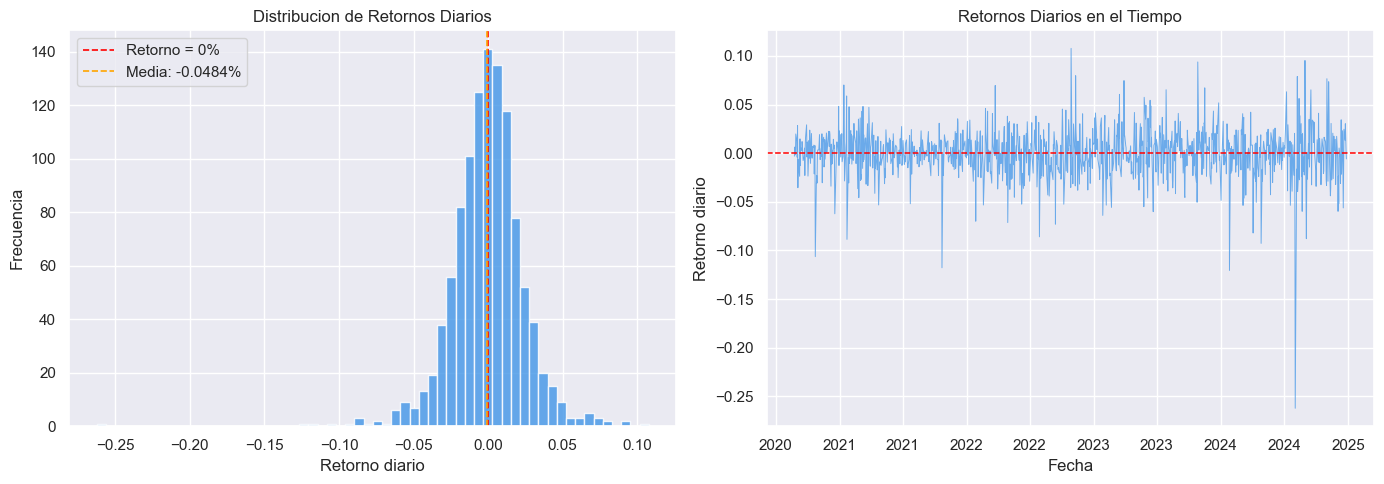

Skewness : -1.2069
Kurtosis : 12.5592
Caida mas grande en un dia  : -26.24%
Subida mas grande en un dia : 10.78%


In [ ]:
#Gráfica 3 — Distribución de retornos diarios
# Analizamos la distribucion de los retornos diarios de INTC
# Si la kurtosis es alta hay mas probabilidad de movimientos bruscos
# Jhonatan calculo daily_return como el pct_change del precio de cierre

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de la distribucion
axes[0].hist(df["daily_return"].dropna(), bins=60,
             color="#4C9BE8", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="red", linestyle="--",
                linewidth=1.2, label="Retorno = 0%")
axes[0].axvline(df["daily_return"].mean(), color="orange", linestyle="--",
                linewidth=1.2, label=f"Media: {df['daily_return'].mean()*100:.4f}%")
axes[0].set_title("Distribucion de Retornos Diarios")
axes[0].set_xlabel("Retorno diario")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Como se ven los retornos a lo largo del tiempo
axes[1].plot(df.index, df["daily_return"],
             color="#4C9BE8", linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.1)
axes[1].set_title("Retornos Diarios en el Tiempo")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Retorno diario")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../plots/03_retornos.png", dpi=150)
plt.show()

print(f"Skewness : {df['daily_return'].skew():.4f}")
print(f"Kurtosis : {df['daily_return'].kurt():.4f}")
print(f"Caida mas grande en un dia  : {df['daily_return'].min()*100:.2f}%")
print(f"Subida mas grande en un dia : {df['daily_return'].max()*100:.2f}%")

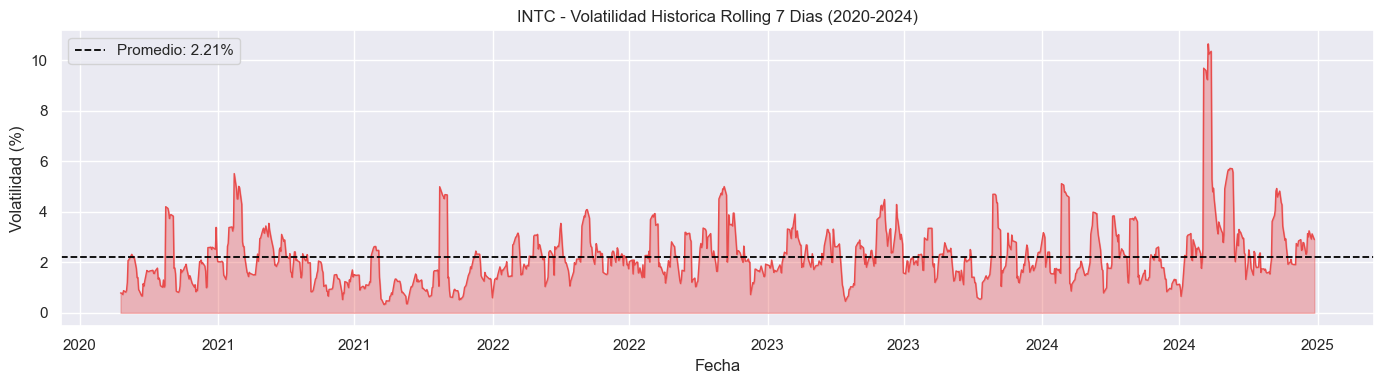

Volatilidad maxima registrada : 10.65%
Volatilidad minima registrada : 0.33%


In [ ]:
#Gráfica 4 — Volatilidad histórica rolling 7 días
# Volatilidad de INTC en ventana de 7 dias
# Calculada por jhonatan como desviacion estandar del retorno diario
# Nos permite ver en que momentos el activo tuvo mayor riesgo

fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(df.index, df["volatility_7"] * 100,
                alpha=0.35, color="#E84C4C")
ax.plot(df.index, df["volatility_7"] * 100, color="#E84C4C", linewidth=1)
ax.axhline(df["volatility_7"].mean() * 100, color="black", linestyle="--",
           linewidth=1.3, label=f"Promedio: {df['volatility_7'].mean()*100:.2f}%")

ax.set_title("INTC - Volatilidad Historica Rolling 7 Dias (2020-2024)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Volatilidad (%)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig("../plots/04_volatilidad.png", dpi=150)
plt.show()

print(f"Volatilidad maxima registrada : {df['volatility_7'].max()*100:.2f}%")
print(f"Volatilidad minima registrada : {df['volatility_7'].min()*100:.2f}%")

C:\Users\jhona\AppData\Local\Temp\ipykernel_39000\4128121788.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="year", y="close", palette="Blues", ax=ax, width=0.5)


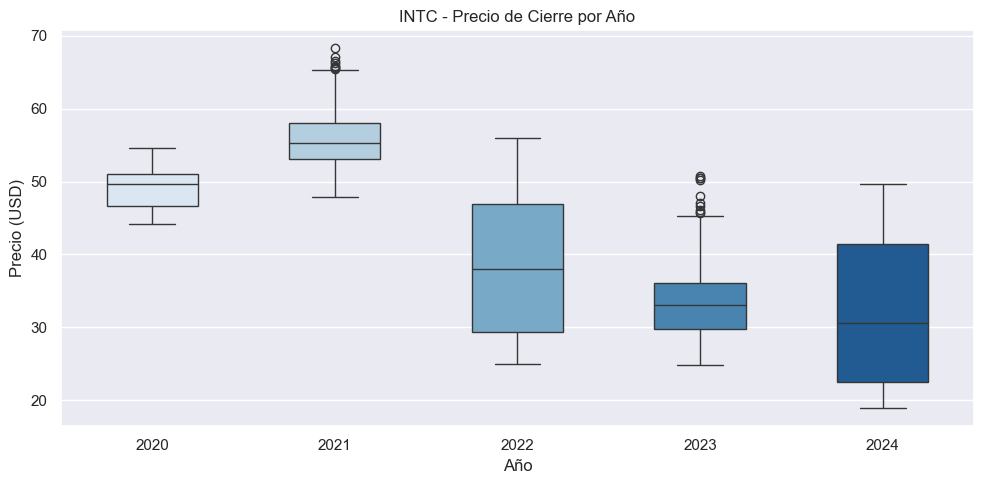

Precio promedio por año:
year
2020    49.20
2021    55.85
2022    38.60
2023    33.83
2024    31.13
Name: close, dtype: float64


In [16]:
#Gráfica 5 — Boxplot del precio por año
# Boxplot para ver como se distribuyo el precio de INTC cada año
# Se puede apreciar claramente la caida de Intel desde 2021 hasta 2024

df["year"] = df.index.year

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="year", y="close", palette="Blues", ax=ax, width=0.5)

ax.set_title("INTC - Precio de Cierre por Año")
ax.set_xlabel("Año")
ax.set_ylabel("Precio (USD)")

plt.tight_layout()
plt.savefig("../plots/05_boxplot_anual.png", dpi=150)
plt.show()

print("Precio promedio por año:")
print(df.groupby("year")["close"].mean().round(2))

df.drop(columns=["year"], inplace=True)

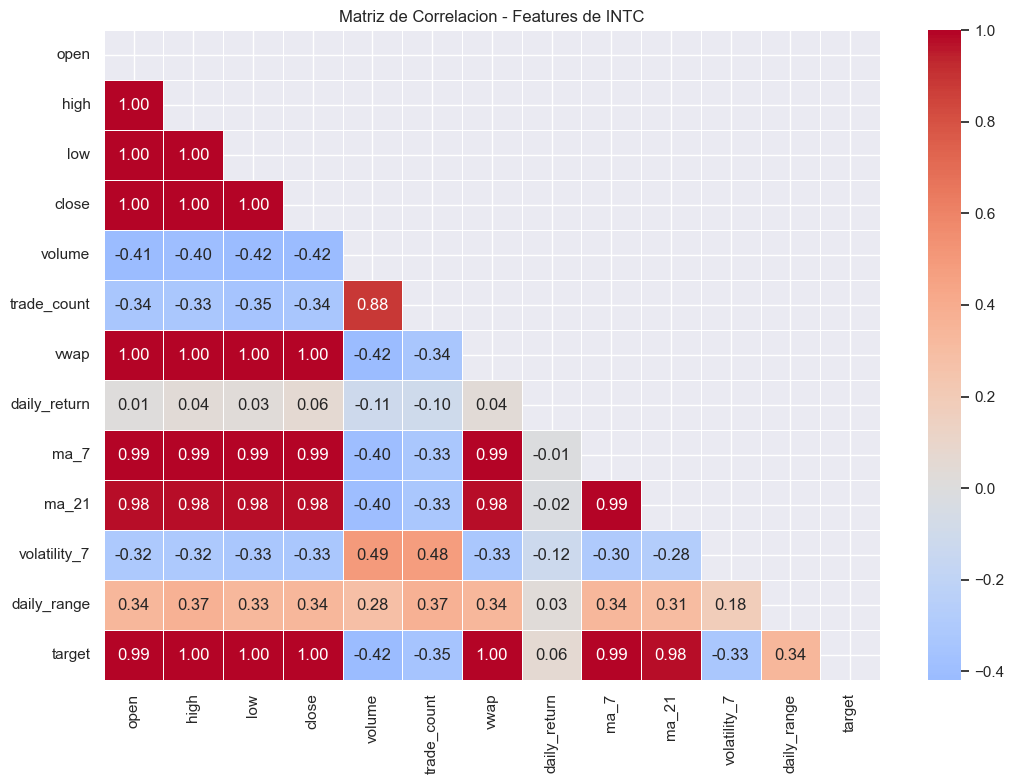

Correlacion de cada variable con el target:
high            1.00
low             1.00
close           1.00
vwap            1.00
open            0.99
ma_7            0.99
ma_21           0.98
daily_range     0.34
daily_return    0.06
volatility_7   -0.33
trade_count    -0.35
volume         -0.42
Name: target, dtype: float64


In [19]:
# Identificación de patrones, tendencias y correlaciones
#Gráfica 6 — Matriz de correlación
# Matriz de correlacion entre todas las variables del dataset
# Lo mas importante es ver que variables tienen mas relacion con el target
# que es el precio de cierre del dia siguiente

corr = df.corr(numeric_only=True).round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5, ax=ax)

ax.set_title("Matriz de Correlacion - Features de INTC")
plt.tight_layout()
plt.savefig("../plots/06_correlacion.png", dpi=150)
plt.show()

# Variables con mayor correlacion con el target
print("Correlacion de cada variable con el target:")
print(corr["target"].drop("target").sort_values(ascending=False).round(4))

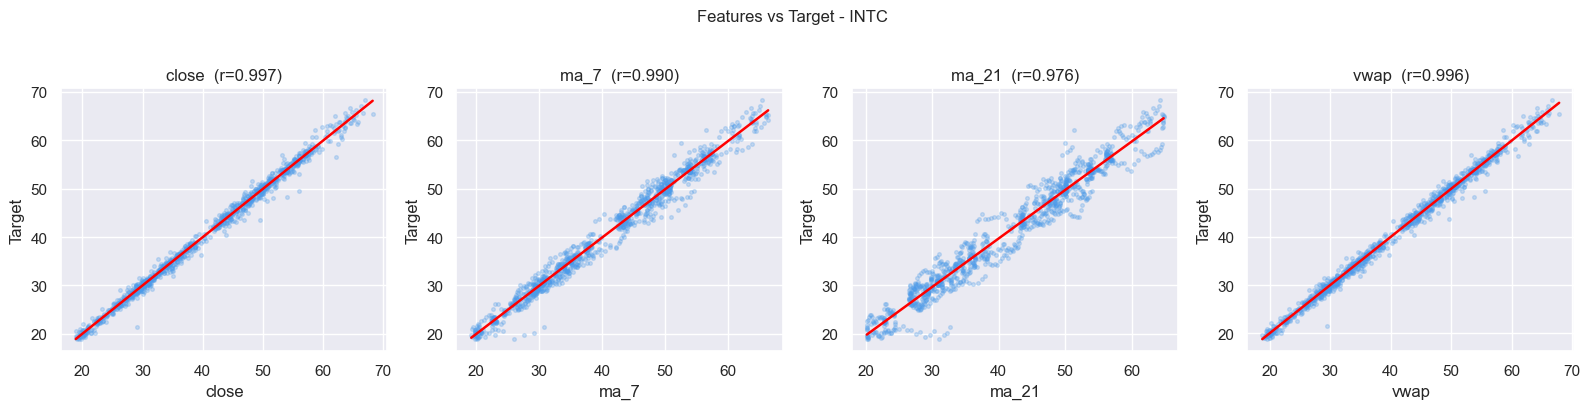

In [ ]:
#Gráfica 7 — Relación entre features y el target
# Scatter de las 4 variables con mayor correlacion con el target
# Si la relacion es lineal los modelos de regresion van a funcionar bien
# Esto justifica el uso de regresion lineal que usara Robert

top = ["close", "ma_7", "ma_21", "vwap"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, top):
    ax.scatter(df[col], df["target"], alpha=0.25, s=7, color="#4C9BE8")
    m, b = np.polyfit(df[col].dropna(), df["target"][df[col].notna()], 1)
    x = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x, m * x + b, color="red", linewidth=1.8)
    r = df[col].corr(df["target"])
    ax.set_title(f"{col}  (r={r:.3f})")
    ax.set_xlabel(col)
    ax.set_ylabel("Target")

plt.suptitle("Features vs Target - INTC", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig("../plots/07_scatter_target.png", dpi=150, bbox_inches="tight")
plt.show()

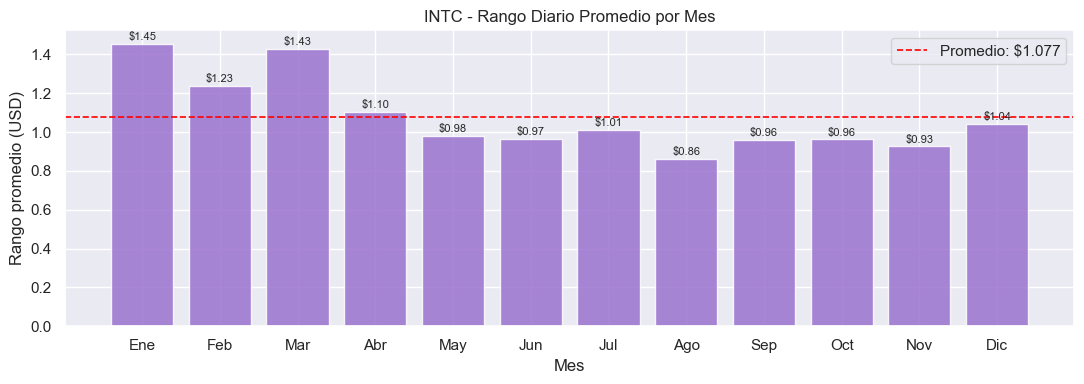

In [21]:
#Gráfica 8 — Estacionalidad del rango diario por mes
# Rango diario promedio agrupado por mes
# Nos dice si hay meses donde INTC se mueve mas que otros
# Los meses de reporte trimestral de Intel (ene, abr, jul, oct)
# suelen tener mayor actividad

df["month"] = df.index.month
meses = ["Ene","Feb","Mar","Abr","May","Jun",
         "Jul","Ago","Sep","Oct","Nov","Dic"]
rango_mes = df.groupby("month")["daily_range"].mean()

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(range(1, 13), rango_mes.values,
              color="#9B72CF", alpha=0.85, edgecolor="white")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)
ax.axhline(rango_mes.mean(), color="red", linestyle="--",
           linewidth=1.2, label=f"Promedio: ${rango_mes.mean():.3f}")

for bar, val in zip(bars, rango_mes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"${val:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_title("INTC - Rango Diario Promedio por Mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Rango promedio (USD)")
ax.legend()

plt.tight_layout()
plt.savefig("../plots/08_estacionalidad.png", dpi=150)
plt.show()

df.drop(columns=["month"], inplace=True)

In [ ]:
#Conclusiones del EDA — Punto 1 
# Resumen de los hallazgos del EDA

print("CONCLUSIONES DEL EDA - INTEL (INTC) 2020-2024")
print("-" * 50)

print(f"""
Dataset:
  {df.shape[0]} registros diarios con {df.shape[1]} features
  Desde {df.index.min().date()} hasta {df.index.max().date()}

Precio:
  Promedio de ${df['close'].mean():.2f} USD con rango de
  ${df['close'].min():.2f} a ${df['close'].max():.2f} USD
  Tendencia alcista hasta 2021 y bajista de 2022 a 2024

Retornos:
  Retorno promedio diario de {df['daily_return'].mean()*100:.4f}%
  El {(df['daily_return'] > 0).mean()*100:.1f}% de los dias fueron positivos
  Kurtosis de {df['daily_return'].kurt():.2f} indica movimientos extremos frecuentes

Volatilidad:
  Promedio del {df['volatility_7'].mean()*100:.4f}% en ventana de 7 dias
  Picos notorios en 2020 (COVID-19) y en 2022-2023

Correlaciones:
  close, vwap, ma_7 y ma_21 tienen correlacion mayor a 0.99 con el target
  Son las features con mayor poder predictivo para los modelos de Persona 3
  daily_return y volatility_7 aportan informacion independiente al modelo

Graficas generadas:
  01_precio_ma.png        - Precio historico con MA7 y MA21
  02_volumen.png          - Volumen diario de transacciones
  03_retornos.png         - Distribucion y serie de retornos
  04_volatilidad.png      - Volatilidad rolling 7 dias
  05_boxplot_anual.png    - Distribucion del precio por año
  06_correlacion.png      - Matriz de correlacion
  07_scatter_target.png   - Relacion features vs target
  08_estacionalidad.png   - Rango diario promedio por mes
""")

CONCLUSIONES DEL EDA - INTEL (INTC) 2020-2024
--------------------------------------------------

Dataset:
  1094 registros diarios con 13 features
  Desde 2020-08-24 hasta 2024-12-27

Precio:
  Promedio de $40.66 USD con rango de
  $18.90 a $68.27 USD
  Tendencia alcista hasta 2021 y bajista de 2022 a 2024

Retornos:
  Retorno promedio diario de -0.0484%
  El 49.5% de los dias fueron positivos
  Kurtosis de 12.56 indica movimientos extremos frecuentes

Volatilidad:
  Promedio del 2.2096% en ventana de 7 dias
  Picos notorios en 2020 (COVID-19) y en 2022-2023

Correlaciones:
  close, vwap, ma_7 y ma_21 tienen correlacion mayor a 0.99 con el target
  Son las features con mayor poder predictivo para los modelos de Persona 3
  daily_return y volatility_7 aportan informacion independiente al modelo

Graficas generadas:
  01_precio_ma.png        - Precio historico con MA7 y MA21
  02_volumen.png          - Volumen diario de transacciones
  03_retornos.png         - Distribucion y serie de r

In [ ]:
#HASTA ACA MI PARTE - OSWALDO